<div align="center">
  <img src="../assets/uepb_logo.png" width="150">
  <br>
  <strong>Universidade Estadual da Paraíba (UEPB)</strong><br>
  <strong>Professor(a):</strong> Thiciany Matsudo Iwano<br>
  <strong>Alunos:</strong> Tarcio Elyakin Agra Diniz & Djhonatah Wesley Cavalcanti Alves<br>
  <strong>Série:</strong> Sistemas Lineares: teoria, interpretação geométrica e aplicações com Python<br>
</div>

---

# [Tutorial 04] Sistemas Lineares e o Teorema de Rouché-Capelli

> **Pré-requisito:** [03] Eliminação de Gauss e Gauss-Jordan (`03_eliminacao_gauss_e_gauss_jordan.ipynb`)  
> **Próximo:** [05] Espaços e Subespaços (`05_espacos_e_subespacos.ipynb`)

---

## Introdução

Neste tutorial, consolidaremos os conceitos de **Posto da Matriz** (Rank) e sua aplicação na classificação de sistemas lineares. O **Teorema de Rouché-Capelli** é a ferramenta teórica fundamental que permite prever a existência e a multiplicidade de soluções para qualquer sistema linear, independentemente de sua dimensão.

Ao final deste tutorial, o estudante será capaz de:
1. Classificar sistemas lineares utilizando a relação entre os postos da matriz de coeficientes e da matriz aumentada.
2. Identificar a existência de variáveis livres e parâmetros de solução.
3. Interpretar geometricamente as soluções de sistemas no espaço tridimensional.
4. Resolver e analisar **Sistemas Homogêneos**.

**Referência principal:** BOLDRINI, J. L. et al. *Álgebra Linear*. 3ª ed. São Paulo: Harper & Row do Brasil, 1980.

## 1. Sistemas Homogêneos

### 1.1 Definição de Sistema Homogêneo (Boldrini)

Um **sistema linear homogêneo** é um sistema da forma

$$A\mathbf{x} = \mathbf{0}$$

isto é, um sistema em que **todos os termos independentes são zero**:

$$\begin{cases}
a_{11}\,x_1 + a_{12}\,x_2 + \cdots + a_{1n}\,x_n = 0 \\
a_{21}\,x_1 + a_{22}\,x_2 + \cdots + a_{2n}\,x_n = 0 \\
\vdots \hspace{5cm} \vdots \\
a_{m1}\,x_1 + a_{m2}\,x_2 + \cdots + a_{mn}\,x_n = 0
\end{cases}$$

> **Propriedade fundamental:** um sistema homogêneo **sempre admite pelo menos uma solução** — a solução $\mathbf{x} = \mathbf{0}$, chamada de **solução trivial**.

Portanto, um sistema homogêneo **nunca é impossível (SI)**. Ele é sempre **SPD** ou **SPI**.

---

### 1.2 Solução Trivial vs. Não Trivial

<table width="100%">
  <thead>
    <tr>
      <th align="left">Tipo de Solução</th>
      <th align="left">Descrição</th>
      <th align="left">Exemplo</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Trivial</strong></td>
      <td>$\mathbf{x} = \mathbf{0}$ (todas as incógnitas são zero)</td>
      <td>$x_1 = 0, x_2 = 0, x_3 = 0$</td>
    </tr>
    <tr>
      <td><strong>Não trivial</strong></td>
      <td>Pelo menos uma incógnita é diferente de zero</td>
      <td>$x_1 = 2, x_2 = -1, x_3 = 0$</td>
    </tr>
  </tbody>
</table>

**Quando existe solução não trivial?**

Pelo Teorema de Rouché-Capelli (Notebook 02), como $\mathbf{b} = \mathbf{0}$, temos sempre $\text{posto}(A) = \text{posto}([A|\mathbf{0}])$. Logo:

- Se $\text{posto}(A) = n$ (nº de incógnitas) → **SPD** → apenas a **solução trivial**
- Se $\text{posto}(A) < n$ → **SPI** → existem **soluções não triviais**

> **Consequência (Boldrini):** Se o número de equações $m$ é **menor** que o número de incógnitas $n$, então $\text{posto}(A) \leq m < n$, e o sistema homogêneo necessariamente possui **soluções não triviais**.

### 1.3 Exemplo Computacional — Sistemas Homogêneos

In [25]:
import sympy as sp

# ── Exemplo 1: Sistema homogêneo com solução APENAS trivial (SPD) ──
print("="*60)
print("Exemplo 1: Sistema homogêneo — apenas solução trivial")
print("  x + 2y = 0")
print("  3x + y = 0")
print("="*60)

A1 = sp.Matrix([[1, 2], [3, 1]])
b1 = sp.Matrix([0, 0])

aug1 = A1.row_join(b1)
rref1, pivots1 = aug1.rref()

print(f"\nMatriz aumentada [A|0]:")
display(aug1)
print(f"\nForma escalonada reduzida (RREF):")
display(rref1)
print(f"Pivôs nas colunas: {pivots1}")
print(f"posto(A) = {A1.rank()}, n = {A1.shape[1]}")
print(f"→ posto(A) = n → Apenas a solução trivial: x = 0, y = 0")

# ── Exemplo 2: Sistema homogêneo com soluções não triviais (SPI) ──
print("\n" + "="*60)
print("Exemplo 2: Sistema homogêneo — soluções não triviais")
print("   x + 2y + 3z = 0")
print("  2x + 4y + 6z = 0")
print("="*60)

A2 = sp.Matrix([[1, 2, 3], [2, 4, 6]])
b2 = sp.Matrix([0, 0])

aug2 = A2.row_join(b2)
rref2, pivots2 = aug2.rref()

print(f"\nForma escalonada reduzida (RREF):")
display(rref2)
print(f"Pivôs nas colunas: {pivots2}")
print(f"posto(A) = {A2.rank()}, n = {A2.shape[1]}")
print(f"→ posto(A) = {A2.rank()} < n = {A2.shape[1]} → Infinitas soluções não triviais")
print(f"→ Graus de liberdade: {A2.shape[1] - A2.rank()}")

# Solução geral com nullspace
print("\nBase do espaço de soluções (núcleo):")
for v in A2.nullspace():
    sp.pprint(v.T)

Exemplo 1: Sistema homogêneo — apenas solução trivial
  x + 2y = 0
  3x + y = 0

Matriz aumentada [A|0]:


Matrix([
[1, 2, 0],
[3, 1, 0]])


Forma escalonada reduzida (RREF):


Matrix([
[1, 0, 0],
[0, 1, 0]])

Pivôs nas colunas: (0, 1)
posto(A) = 2, n = 2
→ posto(A) = n → Apenas a solução trivial: x = 0, y = 0

Exemplo 2: Sistema homogêneo — soluções não triviais
   x + 2y + 3z = 0
  2x + 4y + 6z = 0

Forma escalonada reduzida (RREF):


Matrix([
[1, 2, 3, 0],
[0, 0, 0, 0]])

Pivôs nas colunas: (0,)
posto(A) = 1, n = 3
→ posto(A) = 1 < n = 3 → Infinitas soluções não triviais
→ Graus de liberdade: 2

Base do espaço de soluções (núcleo):
[-2  1  0]
[-3  0  1]


---

## 2. Dependência e Independência Linear

### 2.1 Definição de Dependência e Independência Linear (Boldrini)

Sejam $\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_k$ vetores de $\mathbb{R}^n$.

Dizemos que o conjunto $\{\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_k\}$ é **linearmente dependente (LD)** se existem escalares $\alpha_1, \alpha_2, \ldots, \alpha_k$, **nem todos nulos**, tais que:

$$\alpha_1 \mathbf{v}_1 + \alpha_2 \mathbf{v}_2 + \cdots + \alpha_k \mathbf{v}_k = \mathbf{0}$$

Caso contrário — isto é, se a **única** solução da equação acima for $\alpha_1 = \alpha_2 = \cdots = \alpha_k = 0$ — o conjunto é **linearmente independente (LI)**.

---

### 2.2 Conexão com Sistemas Homogêneos

Verificar se os vetores $\mathbf{v}_1, \ldots, \mathbf{v}_k$ são LI ou LD é **equivalente** a resolver o **sistema homogêneo**:

$$\begin{pmatrix} | & | & & | \\ \mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_k \\ | & | & & | \end{pmatrix} \begin{pmatrix} \alpha_1 \\ \alpha_2 \\ \vdots \\ \alpha_k \end{pmatrix} = \mathbf{0}$$

em que cada vetor $\mathbf{v}_i$ é uma **coluna** da matriz.

| Sistema homogêneo | Resultado | Conclusão |
|-------------------|-----------|----------|
| Apenas solução trivial (SPD) | $\alpha_1 = \cdots = \alpha_k = 0$ | Vetores são **LI** |
| Soluções não triviais (SPI) | Existem $\alpha_i \neq 0$ | Vetores são **LD** |

---

### 2.3 Interpretação Intuitiva

- **LI:** Nenhum vetor do conjunto pode ser escrito como combinação linear dos demais. Cada vetor traz "informação nova".
- **LD:** Pelo menos um vetor é combinação linear dos outros — existe **redundância**.

**Critério prático:** Monte a matriz com os vetores como colunas e escalone. O número de pivôs é o número máximo de vetores LI.

### 2.4 Exemplo — Verificando LI / LD com Eliminação de Gauss

In [26]:
import sympy as sp

# ── Exemplo 1: Vetores LI em R³ ──────────────────────────────
print("="*60)
print("Exemplo 1: Vetores LI em R³")
print("  v1 = (1, 0, 0),  v2 = (0, 1, 0),  v3 = (0, 0, 1)")
print("="*60)

V_li = sp.Matrix([[1, 0, 0],
                   [0, 1, 0],
                   [0, 0, 1]])

rref_li, pivots_li = V_li.rref()
print(f"\nRREF:")
display(rref_li)
print(f"Pivôs nas colunas: {pivots_li}")
print(f"posto = {V_li.rank()} = nº de vetores = {V_li.shape[1]} → Vetores LI ✔")

# ── Exemplo 2: Vetores LD em R³ ──────────────────────────────
print("\n" + "="*60)
print("Exemplo 2: Vetores LD em R³")
print("  v1 = (1, 2, 3),  v2 = (4, 5, 6),  v3 = (5, 7, 9)")
print("  Note: v3 = v1 + v2")
print("="*60)

V_ld = sp.Matrix([[1, 4, 5],
                   [2, 5, 7],
                   [3, 6, 9]])

rref_ld, pivots_ld = V_ld.rref()
print(f"\nRREF:")
display(rref_ld)
print(f"Pivôs nas colunas: {pivots_ld}")
print(f"posto = {V_ld.rank()} < nº de vetores = {V_ld.shape[1]} → Vetores LD ✘")

print("\nRelação de dependência (núcleo):")
for v in V_ld.nullspace():
    print(f"  {v[0]}·v1 + {v[1]}·v2 + {v[2]}·v3 = 0")
    sp.pprint(v.T)

Exemplo 1: Vetores LI em R³
  v1 = (1, 0, 0),  v2 = (0, 1, 0),  v3 = (0, 0, 1)

RREF:


Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

Pivôs nas colunas: (0, 1, 2)
posto = 3 = nº de vetores = 3 → Vetores LI ✔

Exemplo 2: Vetores LD em R³
  v1 = (1, 2, 3),  v2 = (4, 5, 6),  v3 = (5, 7, 9)
  Note: v3 = v1 + v2

RREF:


Matrix([
[1, 0, 1],
[0, 1, 1],
[0, 0, 0]])

Pivôs nas colunas: (0, 1)
posto = 2 < nº de vetores = 3 → Vetores LD ✘

Relação de dependência (núcleo):
  -1·v1 + -1·v2 + 1·v3 = 0
[-1  -1  1]


---

## 3. Núcleo e Imagem de uma Matriz

### 3.1 Definição de Núcleo (Boldrini)

O **núcleo** (ou *kernel*) de uma matriz $A \in \mathbb{R}^{m \times n}$ é o conjunto de todas as soluções do sistema homogêneo $A\mathbf{x} = \mathbf{0}$:

$$\text{Nuc}(A) = \ker(A) = \{\mathbf{x} \in \mathbb{R}^n \mid A\mathbf{x} = \mathbf{0}\}$$

**Propriedades:**
- O núcleo é um **subespaço vetorial** de $\mathbb{R}^n$.
- $\dim(\ker(A))$ = **nulidade** de $A$ = $n - \text{posto}(A)$.
- Se $\ker(A) = \{\mathbf{0}\}$, as colunas de $A$ são **LI**.
- Se $\ker(A) \neq \{\mathbf{0}\}$, as colunas de $A$ são **LD**.

---

### 3.2 Definição de Imagem (Boldrini)

A **imagem** de $A$ é o conjunto de todos os vetores $\mathbf{b}$ que podem ser escritos como $A\mathbf{x}$:

$$\text{Im}(A) = \{A\mathbf{x} \mid \mathbf{x} \in \mathbb{R}^n\}$$

Equivale ao **espaço coluna** de $A$ — o espaço gerado pelas colunas de $A$.

**Propriedades:**
- A imagem é um **subespaço vetorial** de $\mathbb{R}^m$.
- $\dim(\text{Im}(A)) = \text{posto}(A)$.

---

### 3.3 Teorema do Núcleo e da Imagem (Boldrini)

Para qualquer matriz $A \in \mathbb{R}^{m \times n}$:

$$\boxed{\dim(\ker(A)) + \dim(\text{Im}(A)) = n}$$

ou equivalentemente:

$$\boxed{\text{nulidade}(A) + \text{posto}(A) = n}$$

> **Interpretação:** as $n$ "dimensões" das incógnitas se dividem entre as que ficam determinadas (posto) e as que ficam livres (nulidade).

---

### 3.4 Dependência Linear e o Núcleo

A conexão entre dependência linear e núcleo é direta:

| Condição | Núcleo | Dependência |
|----------|--------|------------|
| $\ker(A) = \{\mathbf{0}\}$ | trivial | Colunas de $A$ são **LI** |
| $\ker(A) \neq \{\mathbf{0}\}$ | não trivial | Colunas de $A$ são **LD** |

Cada vetor não nulo do núcleo fornece uma **relação de dependência linear** entre as colunas de $A$.

### 3.5 Calculando Núcleo e Imagem em Python

In [27]:
import sympy as sp

# ── Matriz com colunas LD ────────────────────────────────────
print("="*60)
print("Cálculo do Núcleo e Imagem")
print("="*60)

A = sp.Matrix([
    [1, 2, 3],
    [2, 4, 6],
    [1, 1, 2]
])

print("\nMatriz A:")
display(A)

# Núcleo (nullspace)
nucleo = A.nullspace()
print(f"\n─── Núcleo (ker(A)) ───")
print(f"Dimensão do núcleo (nulidade) = {len(nucleo)}")
if nucleo:
    print("Base do núcleo:")
    display(sp.Matrix.hstack(*nucleo))
else:
    print("  ker(A) = {0}  (apenas a solução trivial)")

# Imagem (columnspace)
imagem = A.columnspace()
print(f"\n─── Imagem (Im(A)) ───")
print(f"Dimensão da imagem (posto) = {len(imagem)}")
print("Base da imagem:")
display(sp.Matrix.hstack(*imagem))

# Verificação do Teorema da Dimensão
n = A.shape[1]
nulidade = len(nucleo)
posto = len(imagem)
print(f"\n─── Teorema da Dimensão ───")
print(f"nulidade + posto = {nulidade} + {posto} = {nulidade + posto}")
print(f"n (nº de colunas) = {n}")
print(f"Verificação: {nulidade} + {posto} = {n} ✔" if nulidade + posto == n else "Erro!")

Cálculo do Núcleo e Imagem

Matriz A:


Matrix([
[1, 2, 3],
[2, 4, 6],
[1, 1, 2]])


─── Núcleo (ker(A)) ───
Dimensão do núcleo (nulidade) = 1
Base do núcleo:


Matrix([
[-1],
[-1],
[ 1]])


─── Imagem (Im(A)) ───
Dimensão da imagem (posto) = 2
Base da imagem:


Matrix([
[1, 2],
[2, 4],
[1, 1]])


─── Teorema da Dimensão ───
nulidade + posto = 1 + 2 = 3
n (nº de colunas) = 3
Verificação: 1 + 2 = 3 ✔


---

## 4. Interpretação Geométrica em 3D

### 4.1 Vetores em $\mathbb{R}^3$

A dependência/independência linear ganha uma interpretação geométrica clara em $\mathbb{R}^3$:

| Nº de vetores LI | Espaço gerado | Geometria |
|-------------------|--------------|----------|
| 1 vetor LI | $\dim = 1$ | **Reta** que passa pela origem |
| 2 vetores LI | $\dim = 2$ | **Plano** que passa pela origem |
| 3 vetores LI | $\dim = 3$ | Todo o $\mathbb{R}^3$ |
| Vetores LD | $\dim < k$ | Os vetores "não abrem" uma nova dimensão |

### 4.2 Interpretação do Núcleo e Imagem em 3D

Para uma matriz $A \in \mathbb{R}^{3 \times 3}$:

| Posto | Nulidade | Imagem | Núcleo |
|-------|----------|--------|--------|
| 3 | 0 | Todo $\mathbb{R}^3$ | $\{\mathbf{0}\}$ (apenas a origem) |
| 2 | 1 | Um plano pela origem | Uma reta pela origem |
| 1 | 2 | Uma reta pela origem | Um plano pela origem |
| 0 | 3 | $\{\mathbf{0}\}$ | Todo $\mathbb{R}^3$ |

### 4.3 Visualização 3D — Vetores LI vs LD

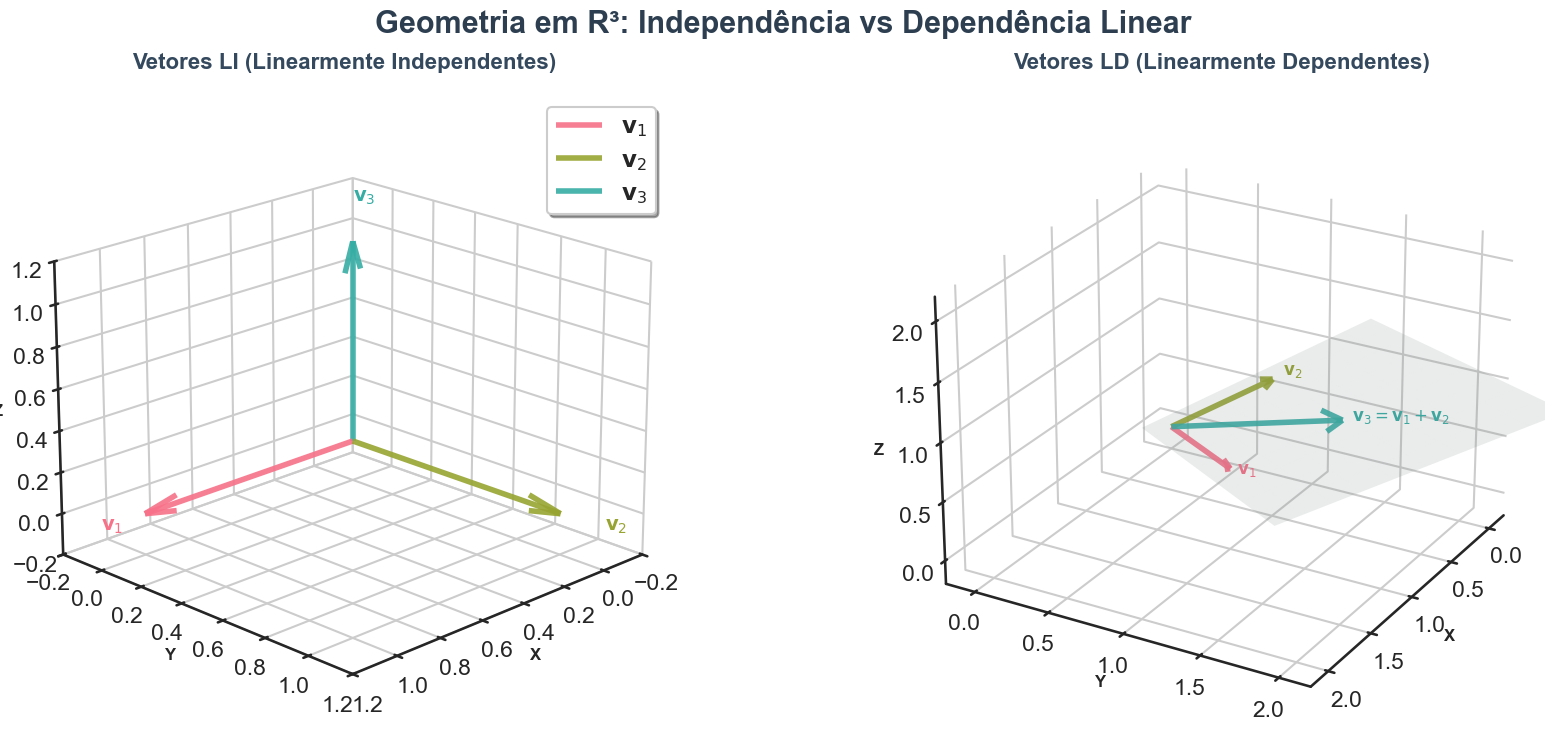

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Configuração do tema Seaborn solicitado
sns.set_theme(style="white", context="talk", palette="muted")

fig = plt.figure(figsize=(18, 8))
fig.suptitle("Geometria em R³: Independência vs Dependência Linear",
             fontsize=22, fontweight='bold', y=0.95, color='#2c3e50')

# Paleta vibrante e moderna
cores = sns.color_palette("husl", 4)

def configurar_eixos_3d(ax, titulo):
    ax.set_title(titulo, fontsize=16, pad=20, weight='bold', color='#34495e')
    ax.set_xlabel('X', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y', fontsize=12, fontweight='bold')
    ax.set_zlabel('Z', fontsize=12, fontweight='bold')
    # Background mais clean
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')
    ax.grid(True, linestyle=':', alpha=0.3)

# ── Vetores LI ──────────────────────────────────────────────
ax1 = fig.add_subplot(121, projection='3d')
configurar_eixos_3d(ax1, "Vetores LI (Linearmente Independentes)")

vetores_li = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
labels_li = [r'$\mathbf{v}_1$', r'$\mathbf{v}_2$', r'$\mathbf{v}_3$']

for i, (v, lbl) in enumerate(zip(vetores_li, labels_li)):
    ax1.quiver(0, 0, 0, v[0], v[1], v[2],
              color=cores[i], arrow_length_ratio=0.15,
              linewidth=4, label=lbl, alpha=0.9)
    ax1.text(v[0]*1.2, v[1]*1.2, v[2]*1.2, lbl, fontsize=14, weight='bold', color=cores[i])

ax1.set_xlim([-0.2, 1.2]); ax1.set_ylim([-0.2, 1.2]); ax1.set_zlim([-0.2, 1.2])
ax1.legend(loc='upper right', frameon=True, shadow=True)
ax1.view_init(elev=20, azim=45)

# ── Vetores LD (coplanares) ─────────────────────────────────
ax2 = fig.add_subplot(122, projection='3d')
configurar_eixos_3d(ax2, "Vetores LD (Linearmente Dependentes)")

v1 = np.array([1, 1, 0.5])
v2 = np.array([0.5, 1, 1])
v3 = v1 + v2  # LD!

vetores_ld = [v1, v2, v3]
labels_ld = [r'$\mathbf{v}_1$', r'$\mathbf{v}_2$', r'$\mathbf{v}_3 = \mathbf{v}_1 + \mathbf{v}_2$']

for i, (v, lbl) in enumerate(zip(vetores_ld, labels_ld)):
    ax2.quiver(0, 0, 0, v[0], v[1], v[2],
              color=cores[i], arrow_length_ratio=0.1,
              linewidth=4, alpha=0.9)
    ax2_text_offset = 1.1 if i < 2 else 1.05
    ax2.text(v[0]*ax2_text_offset, v[1]*ax2_text_offset, v[2]*ax2_text_offset, lbl, 
             fontsize=12, weight='bold', color=cores[i])

# Plano gerado pelos vetores LD para visualização da coplanaridade
s = np.linspace(-0.2, 2.0, 10)
t = np.linspace(-0.2, 2.0, 10)
S, T = np.meshgrid(s, t)
X_plane = S * v1[0] + T * v2[0]
Y_plane = S * v1[1] + T * v2[1]
Z_plane = S * v1[2] + T * v2[2]

ax2.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.15, color='#95a5a6', edgecolor='none')

ax2.set_xlim([-0.2, 2.2]); ax2.set_ylim([-0.2, 2.2]); ax2.set_zlim([-0.2, 2.2])
ax2.view_init(elev=25, azim=30)

plt.tight_layout()
plt.show()

### 4.4 Visualização 3D — Núcleo e Imagem

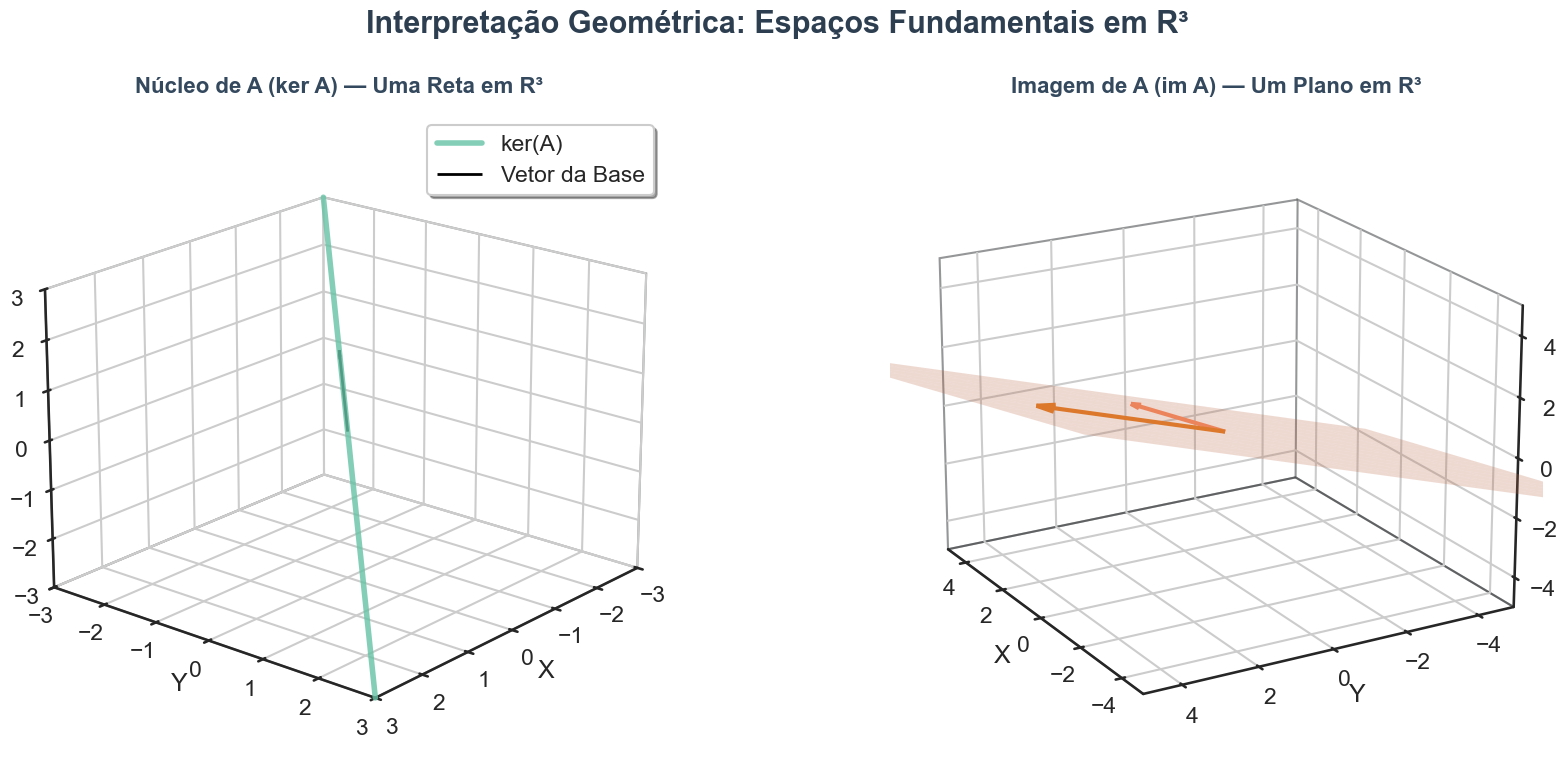

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import seaborn as sns

# Estética refinada com Seaborn tema 'white'
sns.set_theme(style="white", context="talk")

# Matriz de posto 2 (nulidade 1)
A = np.array([[1, 2, 3],
              [2, 4, 6],
              [1, 1, 2]], dtype=float)

A_sp = sp.Matrix(A)
nucleo = A_sp.nullspace()
imagem = A_sp.columnspace()

fig = plt.figure(figsize=(18, 8))
fig.suptitle("Interpretação Geométrica: Espaços Fundamentais em R³",
             fontsize=22, fontweight='bold', y=0.98, color='#2c3e50')

# Cores vibrantes
cores = sns.color_palette("Set2", 4)
cor_nuc = cores[0]
cor_img = cores[1]

def estilizar_3d(ax, titulo):
    ax.set_title(titulo, fontsize=16, pad=15, weight='bold', color='#34495e')
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

# ── Núcleo (ker A) — Reta ───────────────────────────────────
ax1 = fig.add_subplot(121, projection='3d')
estilizar_3d(ax1, "Núcleo de A (ker A) — Uma Reta em R³")

# Vetor do núcleo
n_vec = np.array([float(nucleo[0][i]) for i in range(3)])
t_vals = np.linspace(-3, 3, 100)
nuc_line = np.outer(t_vals, n_vec)

ax1.plot(nuc_line[:, 0], nuc_line[:, 1], nuc_line[:, 2],
         color=cor_nuc, linewidth=4, label='ker(A)', alpha=0.8, zorder=5)
ax1.quiver(0, 0, 0, n_vec[0], n_vec[1], n_vec[2], color='black', 
           linewidth=2, arrow_length_ratio=0.1, label='Vetor da Base')

ax1.set_xlim([-3, 3]); ax1.set_ylim([-3, 3]); ax1.set_zlim([-3, 3])
ax1.legend(frameon=True, shadow=True)
ax1.view_init(elev=20, azim=40)

# ── Imagem (im A) — Plano ───────────────────────────────────
ax2 = fig.add_subplot(122, projection='3d')
estilizar_3d(ax2, "Imagem de A (im A) — Um Plano em R³")

# Vetores da base da imagem
v1_img = np.array([float(imagem[0][i]) for i in range(3)])
v2_img = np.array([float(imagem[1][i]) for i in range(3)])

# Malha para o plano da imagem
s_vals = np.linspace(-1.5, 1.5, 15)
t_vals2 = np.linspace(-1.5, 1.5, 15)
S, T = np.meshgrid(s_vals, t_vals2)
X_im = S * v1_img[0] + T * v2_img[0]
Y_im = S * v1_img[1] + T * v2_img[1]
Z_im = S * v1_img[2] + T * v2_img[2]

ax2.plot_surface(X_im, Y_im, Z_im, color=cor_img, alpha=0.25, edgecolor='none')
ax2.quiver(0, 0, 0, v1_img[0], v1_img[1], v1_img[2], color=cor_img, linewidth=3, arrow_length_ratio=0.1)
ax2.quiver(0, 0, 0, v2_img[0], v2_img[1], v2_img[2], color='#e67e22', linewidth=3, arrow_length_ratio=0.1)

ax2.set_xlim([-5, 5]); ax2.set_ylim([-5, 5]); ax2.set_zlim([-5, 5])
ax2.view_init(elev=20, azim=150)

plt.tight_layout()
plt.show()

---

## 5. Conexão com a Eliminação de Gauss

### 5.1 O Escalonamento Revela Tudo

A **eliminação de Gauss** (Notebook 03) não serve apenas para resolver sistemas — ela é a ferramenta fundamental para:

| O que descobrir | Como usar o escalonamento |
|-----------------|-------------------------|
| **Posto** de $A$ | Contar o número de **pivôs** na forma escalonada |
| **Nulidade** de $A$ | $n - \text{nº de pivôs}$ |
| **Base do núcleo** | Resolver $A\mathbf{x} = \mathbf{0}$ pela RREF |
| **Base da imagem** | Colunas de $A$ correspondentes às colunas com pivô |
| **LI ou LD** | Se todas as colunas têm pivô → LI; senão → LD |
| **Classificação** | SPD/SPI/SI via Rouché-Capelli |

---

### 5.2 Algoritmo Completo

Dado um conjunto de vetores $\{\mathbf{v}_1, \ldots, \mathbf{v}_k\}$:

1. Monte a matriz $V = [\mathbf{v}_1 \mid \mathbf{v}_2 \mid \cdots \mid \mathbf{v}_k]$
2. Escalone $V$ até a RREF
3. Conte os pivôs → **posto** de $V$
4. Se posto $= k$ → vetores são **LI**
5. Se posto $< k$ → vetores são **LD**
6. As variáveis livres (colunas sem pivô) geram o **núcleo**
7. As colunas **originais** correspondentes aos pivôs formam uma base da **imagem**

### 5.3 Exemplo Completo — Da Eliminação à Classificação

In [30]:
import sympy as sp

print("="*60)
print("Análise completa via Eliminação de Gauss")
print("="*60)

A = sp.Matrix([
    [1,  2, -1,  3],
    [2,  4,  0,  8],
    [3,  6, -1, 11]
])

print("\nMatriz A (3×4):")
display(A)

# 1. RREF
rref_A, pivots = A.rref()
print("\n─── Passo 1: RREF ───")
display(rref_A)

# 2. Posto e nulidade
posto = A.rank()
n = A.shape[1]
nulidade = n - posto
print(f"\n─── Passo 2: Posto e Nulidade ───")
print(f"Colunas com pivô: {pivots}")
print(f"Posto = {posto}")
print(f"Nulidade = n - posto = {n} - {posto} = {nulidade}")

# 3. Núcleo
print(f"\n─── Passo 3: Núcleo ───")
nucleo = A.nullspace()
print(f"Dimensão do núcleo = {len(nucleo)}")
if nucleo:
    print("Base do núcleo:")
    display(sp.Matrix.hstack(*nucleo))

# 4. Imagem
print(f"\n─── Passo 4: Imagem ───")
imagem = A.columnspace()
print(f"Dimensão da imagem = {len(imagem)}")
if imagem:
    print("Base da imagem:")
    display(sp.Matrix.hstack(*imagem))

# 5. Dependência Linear
print(f"\n─── Passo 5: Conclusão ───")
if nulidade == 0:
    print("As colunas de A são LINEARMENTE INDEPENDENTES (LI)")
else:
    print(f"As colunas de A são LINEARMENTE DEPENDENTES (LD)")
    print(f"Existem {nulidade} relação(ões) de dependência")

# 6. Verificação do Teorema da Dimensão
print(f"\n─── Teorema da Dimensão ───")
print(f"dim(ker) + dim(Im) = {nulidade} + {posto} = {nulidade + posto} = n ✔")

Análise completa via Eliminação de Gauss

Matriz A (3×4):


Matrix([
[1, 2, -1,  3],
[2, 4,  0,  8],
[3, 6, -1, 11]])


─── Passo 1: RREF ───


Matrix([
[1, 2, 0, 4],
[0, 0, 1, 1],
[0, 0, 0, 0]])


─── Passo 2: Posto e Nulidade ───
Colunas com pivô: (0, 2)
Posto = 2
Nulidade = n - posto = 4 - 2 = 2

─── Passo 3: Núcleo ───
Dimensão do núcleo = 2
Base do núcleo:


Matrix([
[-2, -4],
[ 1,  0],
[ 0, -1],
[ 0,  1]])


─── Passo 4: Imagem ───
Dimensão da imagem = 2
Base da imagem:


Matrix([
[1, -1],
[2,  0],
[3, -1]])


─── Passo 5: Conclusão ───
As colunas de A são LINEARMENTE DEPENDENTES (LD)
Existem 2 relação(ões) de dependência

─── Teorema da Dimensão ───
dim(ker) + dim(Im) = 2 + 2 = 4 = n ✔


---

## 6. Exercícios

### Exercício 1 — Sistema Homogêneo

Determine se o sistema homogêneo abaixo possui apenas a solução trivial ou soluções não triviais:

$$\begin{cases} x - 2y + z = 0 \\ 2x - 4y + 2z = 0 \\ 3x - 6y + 3z = 0 \end{cases}$$

<details>
<summary>▶ Solução</summary>

A 2ª equação é $2\times$ a 1ª e a 3ª é $3\times$ a 1ª. Logo $\text{posto}(A) = 1 < 3 = n$.

O sistema é **SPI** com $3 - 1 = 2$ graus de liberdade → existem **infinitas soluções não triviais**.

Fazendo $y = s$ e $z = t$: $x = 2s - t$.

Solução geral: $(x, y, z) = s(2, 1, 0) + t(-1, 0, 1)$
</details>

---

### Exercício 2 — LI ou LD?

Verifique se os vetores são LI ou LD:

$$\mathbf{v}_1 = (1, 2, 1), \quad \mathbf{v}_2 = (3, 1, -1), \quad \mathbf{v}_3 = (5, 5, 1)$$

<details>
<summary>▶ Solução</summary>

Monte a matriz $V = [\mathbf{v}_1 | \mathbf{v}_2 | \mathbf{v}_3]$ e escalone:

$$V = \begin{pmatrix} 1 & 3 & 5 \\ 2 & 1 & 5 \\ 1 & -1 & 1 \end{pmatrix}$$

Após escalonar: $\text{posto}(V) = 2 < 3$.

Note que $\mathbf{v}_3 = 2\mathbf{v}_1 + \mathbf{v}_2$.

**Conclusão:** vetores **LD**.
</details>

---

### Exercício 3 — Núcleo e Imagem

Para a matriz abaixo, calcule o núcleo, a imagem e verifique o Teorema da Dimensão:

$$A = \begin{pmatrix} 1 & 3 & 5 \\ 2 & 1 & 5 \\ 1 & -1 & 1 \end{pmatrix}$$

<details>
<summary>▶ Solução</summary>

- $\text{posto}(A) = 2$
- $\text{nulidade}(A) = 3 - 2 = 1$
- Base do núcleo: $\ker(A) = \text{span}\{(-2, -1, 1)\}$  (reta em $\mathbb{R}^3$)
- Base da imagem: colunas 1 e 2 de $A$ (plano em $\mathbb{R}^3$)
- Teorema da Dimensão: $1 + 2 = 3 = n$ ✔
</details>

---

### Exercício 4 (desafio)

Para quais valores de $k$ os vetores abaixo são LI?

$$\mathbf{v}_1 = (1, k, 0), \quad \mathbf{v}_2 = (0, 1, k), \quad \mathbf{v}_3 = (k, 0, 1)$$

<details>
<summary>▶ Solução</summary>

Os vetores são LI se e somente se $\det([\mathbf{v}_1 | \mathbf{v}_2 | \mathbf{v}_3]) \neq 0$.

$$\det = \begin{vmatrix} 1 & 0 & k \\ k & 1 & 0 \\ 0 & k & 1 \end{vmatrix} = 1(1) - 0 + k(k^2 - 0) = 1 + k^3$$

Portanto: $1 + k^3 \neq 0 \implies k \neq -1$.

**Conclusão:** os vetores são LI para $k \neq -1$.
</details>

---

## 7. Conclusão e Transição para Transformações Lineares

### O que vimos neste notebook

| Tópico | Ponto-chave |
|--------|-------------|
| Sistemas homogêneos | $A\mathbf{x} = \mathbf{0}$ sempre tem solução; soluções não triviais existem quando $\text{posto}(A) < n$ |
| Solução trivial vs não trivial | Trivial: $\mathbf{x}=\mathbf{0}$; não trivial: pelo menos uma componente $\neq 0$ |
| Dependência linear | Existe combinação linear não trivial que resulta em $\mathbf{0}$ |
| Independência linear | A única combinação que dá $\mathbf{0}$ é a trivial |
| Núcleo (kernel) | Espaço de soluções de $A\mathbf{x} = \mathbf{0}$; mede a "redundância" |
| Imagem (column space) | Espaço gerado pelas colunas de $A$; mede o "alcance" |
| Teorema da Dimensão | $\text{nulidade} + \text{posto} = n$ |
| Eliminação de Gauss | Ferramenta unificadora: posto, nulidade, LI/LD, núcleo, imagem |

---
## Próximo Passo

Você agora tem a intuição geométrica necessária para entender o "espaço" onde as soluções vivem! Vimos como o posto e a nulidade definem a estrutura de um sistema.

No próximo tutorial, vamos mergulhar nos fundamentos teóricos que sustentam tudo o que vimos até aqui: os Espaços Vetoriais.

👉 **[Ir para o Tutorial 05: Espaços e Subespaços](./05_espacos_e_subespacos.ipynb)**

---
> **"Linear algebra is the mathematics of the 21st century."** — *Stephen Boyd*